In [1]:
# ENV_NAME = "MiniGrid-Empty-16x16-v0"
# OFFLINE_DATASET_VERSION = 5

ENV_NAME = "MiniGrid-LavaGapS5-v0"
OFFLINE_DATASET_VERSION = 0
ENV_SEED = 42

## Train expert policy w/ online RL

In [2]:
import os
import sys

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium import spaces
from rl_zoo3.train import train
from stable_baselines3 import PPO
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import minari
from minari import DataCollector


torch.manual_seed(42)

/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/a1111/micromamba/envs/corl-minari-nocuda/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class MinigridFeaturesExtractor(BaseFeaturesExtractor):
    def __init__(self, observation_space: gym.Space, features_dim: int = 512,
                 normalized_image: bool = False) -> None:
        super().__init__(observation_space, features_dim)
        n_input_channels = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 16, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(16, 32, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, (2, 2)),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            obs_tensor = torch.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(obs_tensor).shape[1]
        
        self.linear = nn.Sequential(nn.Linear(n_flatten, features_dim), nn.ReLU())
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(self.cnn(x))

In [4]:
# # TRAIN EXPERT POLICY

# import minigrid
# from minigrid.wrappers import ImgObsWrapper

# policy_kwargs = dict(
#     features_extractor_class=MinigridFeaturesExtractor,
#     features_extractor_kwargs=dict(features_dim=128)
# )

# env = gym.make(ENV_NAME)
# env = ImgObsWrapper(env)

# model = PPO("CnnPolicy", env, policy_kwargs=policy_kwargs, verbose=1)
# model.learn(2e5)

# # Save current model as best model
# model.save(f"./logs/ppo/{ENV_NAME}/best_model")

In [5]:
from gymnasium.utils import RecordConstructorArgs
from minigrid.wrappers import ImgObsWrapper as MGImgObsWrapper

class RecordedImgObsWrapper(MGImgObsWrapper, RecordConstructorArgs):
    def __init__(self, env):
        RecordConstructorArgs.__init__(self)
        super().__init__(env)

In [6]:
# # COLLECT OFFLINE DATASET 

# env = DataCollector(RecordedImgObsWrapper(gym.make(ENV_NAME)), data_format="parquet")
# path = os.path.abspath('') + f'/logs/ppo/{ENV_NAME}/best_model'
# agent = PPO.load(path)

# total_episodes = 1_000
# # total_episodes = 1

# for _ in tqdm(range(total_episodes)):
#     obs, _ = env.reset()
#     terminated = False
#     truncated = False
#     while not (terminated or truncated):
#         action, _ = agent.predict(obs, deterministic=True)
#         obs, rew, terminated, truncated, info = env.step(action)

In [7]:
# dataset_name = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
# dataset = env.create_dataset(
#     dataset_id=dataset_name,
#     algorithm_name="ExpertPolicy",
#     code_permalink="https://minari.farama.org/tutorials/behavioral_cloning",
#     author="Farama",
#     author_email="contact@farama.org",
# )

# print(f"Collected dataset:\n{dataset_name}")

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PolicyNetwork(nn.Module):
    def __init__(self, observation_space, output_dim):
        super().__init__()

        obs_shape = observation_space.shape
        input_channels = obs_shape[2] if len(obs_shape) == 3 else 1

        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 16, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(16, 32, (2, 2)),
            nn.ReLU(),
            nn.Conv2d(32, 64, (2, 2)),
            nn.ReLU(),
            nn.Flatten()
        )

        with torch.no_grad():
            sample_obs = observation_space.sample()
            sample_obs = torch.from_numpy(sample_obs).permute(2, 0, 1).unsqueeze(0).float() if len(obs_shape) == 3 else torch.from_numpy(sample_obs).unsqueeze(0).unsqueeze(0).float()
            n_flatten = self.cnn(sample_obs).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, 512),
            nn.ReLU()
        )
        self.head = nn.Linear(512, output_dim)

    def forward(self, x):
        # Expect either (B,H,W,C) or (H,W,C)
        if x.dim() == 3:
            x = x.permute(2, 0, 1).unsqueeze(0)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)
        else:
            raise NotImplementedError(f"Expected 3 or 4 dimensions, got {x.dim()}")
        features = self.linear(self.cnn(x.float()))
        logits = self.head(features)
        return logits

In [9]:
def collate_fn(batch):
    """Create episode-major padded batches with mask.

    Returns tensors with shape [B, T, ...] and a boolean mask [B, T]
    indicating valid (non-padded) time steps.
    """
    obs_list = []
    actions_list = []
    rewards_list = []
    terminations_list = []
    truncations_list = []
    lengths = []

    for ep in batch:
        frames = np.asarray(ep.observations, dtype=np.float32)
        if frames.ndim == 3:
            frames = frames[None, ...]

        T = len(ep.actions)
        frames = frames[:T]
        obs_list.append(torch.from_numpy(frames))
        actions_list.append(torch.as_tensor(ep.actions))
        rewards_list.append(torch.as_tensor(ep.rewards))
        terminations_list.append(torch.as_tensor(ep.terminations))
        truncations_list.append(torch.as_tensor(ep.truncations))
        lengths.append(T)

    B = len(batch)
    max_T = max(lengths)

    obs0 = obs_list[0]
    obs_shape = obs0.shape[1:]

    observations = torch.zeros((B, max_T) + obs_shape, dtype=torch.float32)
    actions = torch.full((B, max_T), -1, dtype=torch.long)
    rewards = torch.zeros((B, max_T), dtype=torch.float32)
    terminations = torch.zeros((B, max_T), dtype=torch.bool)
    truncations = torch.zeros((B, max_T), dtype=torch.bool)
    mask = torch.zeros((B, max_T), dtype=torch.bool)
    ids = torch.empty((B, max_T), dtype=torch.long)

    for i, (obs_i, act_i, rew_i, term_i, trunc_i, T_i) in enumerate(
        zip(obs_list, actions_list, rewards_list, terminations_list, truncations_list, lengths)
    ):
        observations[i, :T_i] = obs_i
        actions[i, :T_i] = act_i
        rewards[i, :T_i] = rew_i
        terminations[i, :T_i] = term_i
        truncations[i, :T_i] = trunc_i
        mask[i, :T_i] = True
        ids[i, :T_i] = batch[i].id

    lengths_tensor = torch.as_tensor(lengths, dtype=torch.long)

    return {
        "id": ids,
        "observations": observations,
        "actions": actions,
        "rewards": rewards,
        "terminations": terminations,
        "truncations": truncations,
        "mask": mask,
        "lengths": lengths_tensor,
    }

In [46]:
# Train CRR

DATASET_NAME = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
NUM_EPOCHS = 6
EVAL_EVERY_N_EPOCHS = 2
N_EVAL_ENVS = 100

# ADVANATAGE_BASELINE = 'mean' # or 'max'
ADVANATAGE_BASELINE = 'max' # or 'max'

# WEIGHT_TYPE = 'binary' # or 'exp'
WEIGHT_TYPE = 'exp' # or 'exp'

TEMPERATURE = 0.5

GAMMA = 0.9
TARGET_UPDATE_EVERY_N_STEPS = 4

minari_dataset = minari.load_dataset(DATASET_NAME)
dataloader = DataLoader(minari_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)

env = minari_dataset.recover_environment()
observation_space = env.observation_space
action_space = env.action_space
assert isinstance(observation_space, spaces.Box)
assert isinstance(action_space, spaces.Discrete)

online_net_actor = PolicyNetwork(observation_space, action_space.n)
online_net_critic = PolicyNetwork(observation_space, action_space.n)

target_net_actor = PolicyNetwork(observation_space, action_space.n)
target_net_critic = PolicyNetwork(observation_space, action_space.n)

optimizer_actor = torch.optim.Adam(online_net_actor.parameters())
optimizer_critic = torch.optim.Adam(online_net_critic.parameters())

ce_loss = nn.CrossEntropyLoss(reduction='none')
mse_loss = nn.MSELoss()

eval_env = minari_dataset.recover_environment(render_mode="rgb_array")

for epoch in range(NUM_EPOCHS):
    for batch in dataloader:
        obs = batch["observations"]
        actions = batch["actions"]
        mask = batch["mask"]
        rewards = batch["rewards"]
        dones = (batch["terminations"] | batch["truncations"]).float()
        obs_next = torch.roll(obs, shifts=-1, dims=1)

        B, T = actions.shape[:2]
        obs = obs.reshape(B * T, *obs.shape[2:])
        obs_next = obs_next.reshape(B * T, *obs_next.shape[2:])
        actions = actions.reshape(B * T)
        mask_flat = mask.reshape(B * T)
        rewards = rewards.reshape(B * T)
        dones = dones.reshape(B * T)

        obs = obs[mask_flat]
        obs_next = obs_next[mask_flat]
        actions = actions[mask_flat].long()
        rewards = rewards[mask_flat]
        dones = dones[mask_flat]

        actor_logits = online_net_actor(obs)
        online_actions = actor_logits.argmax(dim=1)

        # compute advantage
        with torch.no_grad():
            q_pred_all = online_net_critic(obs)
            q_pred = torch.take_along_dim(q_pred_all, online_actions.unsqueeze(1), dim=1).squeeze(1)
            if ADVANATAGE_BASELINE == 'mean':
                baseline = q_pred_all.mean(dim=1)
            elif ADVANATAGE_BASELINE == 'max':
                baseline = q_pred_all.amax(dim=1)
            else:
                raise NotImplementedError
            advantage = (q_pred - baseline)

        # compute per-action weights
        if WEIGHT_TYPE == 'binary':
            weights = advantage > 0
        elif WEIGHT_TYPE == 'exp':
            assert TEMPERATURE is not None
            weights = torch.exp(advantage / TEMPERATURE)
        weights = weights.detach()
        
        # compute & weight the actor's loss per-sample
        actor_loss = ce_loss(actor_logits, actions)
        actor_loss = (actor_loss * weights).mean()
        optimizer_actor.zero_grad()
        actor_loss.backward()
        optimizer_actor.step()

        # compute the TD-targets
        with torch.no_grad():
            tgt_actions = target_net_actor(obs).argmax(dim=1)
            tgt_qvalues_all = target_net_critic(obs_next)

            tgt_qvalues_next = torch.take_along_dim(
                tgt_qvalues_all, 
                tgt_actions.unsqueeze(1), 
                dim=1
            ).squeeze(1)
            bellman_tgts = rewards + GAMMA * (1 - dones) * tgt_qvalues_next
        
        # compute critic loss
        critic_qvalues = online_net_critic(obs)                 # shape: [N, num_actions]
        critic_qvalues_chosen = torch.take_along_dim(
            critic_qvalues,                                     # shape: [N, num_actions]
            actions.unsqueeze(1),                               # shape: [N, 1]
            dim=1
        ).squeeze(1)                                            # shape: [N]

        # bellman_tgts shape: [N]
        critic_loss = mse_loss(critic_qvalues_chosen, bellman_tgts)
        optimizer_critic.zero_grad()
        critic_loss.backward()
        optimizer_critic.step()

        # update target nets
        if (epoch + 1) % TARGET_UPDATE_EVERY_N_STEPS == 0:
            target_net_critic.load_state_dict(online_net_critic.state_dict())
            target_net_actor.load_state_dict(online_net_actor.state_dict())
        
    print(f"Epoch: {epoch+1}/{NUM_EPOCHS}, Actor Loss: {actor_loss.item():.6f}, Critic Loss: {critic_loss.item():.3f}")

    if (epoch + 1) % EVAL_EVERY_N_EPOCHS == 0:
        scores = []
        for i in range(N_EVAL_ENVS):
            obs, _ = eval_env.reset(seed=ENV_SEED)
            terminated, truncated = False, False
            accumulated_rew = 0
            while not (terminated or truncated):
                with torch.no_grad():
                    action = online_net_actor(torch.Tensor(obs)).argmax().item()
                obs, reward, terminated, truncated, _ = eval_env.step(action)
                accumulated_rew += reward
            scores.append(accumulated_rew)
        mean_score = sum(scores) / len(scores)
        print(f"Eval at epoch {epoch+1}: reward@{N_EVAL_ENVS} = {mean_score:.2f}")

model_dir = f"checkpoints/offline/crr_weight={WEIGHT_TYPE}_adv={ADVANATAGE_BASELINE}/{DATASET_NAME}"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "policy_latest.pt")
torch.save(online_net_actor.state_dict(), model_path)

Epoch: 1/6, Actor Loss: 1.166484, Critic Loss: 0.080
Epoch: 2/6, Actor Loss: 0.766221, Critic Loss: 0.040
Eval at epoch 2: reward@100 = 0.00
Epoch: 3/6, Actor Loss: 0.463837, Critic Loss: 0.017
Epoch: 4/6, Actor Loss: 0.294767, Critic Loss: 0.060
Eval at epoch 4: reward@100 = 0.95
Epoch: 5/6, Actor Loss: 0.165490, Critic Loss: 0.032
Epoch: 6/6, Actor Loss: 0.102340, Critic Loss: 0.016
Eval at epoch 6: reward@100 = 0.95


In [ ]:
# Train BC

DATASET_NAME = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
NUM_EPOCHS = 12
EVAL_EVERY_N_EPOCHS = 2
N_EVAL_ENVS = 100

minari_dataset = minari.load_dataset(DATASET_NAME)
dataloader = DataLoader(minari_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)

env = minari_dataset.recover_environment()
observation_space = env.observation_space
action_space = env.action_space
assert isinstance(observation_space, spaces.Box)
assert isinstance(action_space, spaces.Discrete)

net_policy = PolicyNetwork(observation_space, action_space.n)
optimizer_policy = torch.optim.Adam(net_policy.parameters())
loss_fn = nn.CrossEntropyLoss()

eval_env = minari_dataset.recover_environment(render_mode="rgb_array")

for epoch in range(NUM_EPOCHS):
    for batch in dataloader:
        obs = batch["observations"]
        actions = batch["actions"]
        mask = batch["mask"]

        B, T = actions.shape[:2]
        obs = obs.reshape(B * T, *obs.shape[2:])
        actions = actions.reshape(B * T)
        mask_flat = mask.reshape(B * T)

        obs = obs[mask_flat]
        actions = actions[mask_flat].long()

        a_pred = net_policy(obs)
        loss = loss_fn(a_pred, actions)

        optimizer_policy.zero_grad()
        loss.backward()
        optimizer_policy.step()

    print(f"Epoch: {epoch+1}/{NUM_EPOCHS}, Loss: {loss.item():.3f}")

    if (epoch + 1) % EVAL_EVERY_N_EPOCHS == 0:
        scores = []
        for i in range(N_EVAL_ENVS):
            obs, _ = eval_env.reset(seed=ENV_SEED)
            terminated, truncated = False, False
            accumulated_rew = 0
            while not (terminated or truncated):
                with torch.no_grad():
                    action = net_policy(torch.Tensor(obs)).argmax().item()
                obs, reward, terminated, truncated, _ = eval_env.step(action)
                accumulated_rew += reward
            scores.append(accumulated_rew)
        mean_score = sum(scores) / len(scores)
        print(f"Eval at epoch {epoch+1}: reward@{N_EVAL_ENVS} = {mean_score:.2f}")

model_dir = f"checkpoints/offline/bc/{DATASET_NAME}"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "policy_latest.pt")
torch.save(net_policy.state_dict(), model_path)

Epoch: 0/12, Loss: 1.196
Epoch: 1/12, Loss: 0.758
Eval at epoch 2: reward@100 = 0.00
Epoch: 2/12, Loss: 0.545
Epoch: 3/12, Loss: 0.373
Eval at epoch 4: reward@100 = 0.95
Epoch: 4/12, Loss: 0.249
Epoch: 5/12, Loss: 0.171
Eval at epoch 6: reward@100 = 0.95
Epoch: 6/12, Loss: 0.108
Epoch: 7/12, Loss: 0.061
Eval at epoch 8: reward@100 = 0.95
Epoch: 8/12, Loss: 0.033
Epoch: 9/12, Loss: 0.016
Eval at epoch 10: reward@100 = 0.95
Epoch: 10/12, Loss: 0.010
Epoch: 11/12, Loss: 0.005
Eval at epoch 12: reward@100 = 0.95


In [56]:
# Train (Double) Deep Q-learning (DQN w/hard copy update rule)

from copy import deepcopy

DATASET_NAME = f"{ENV_NAME}/expert-v{OFFLINE_DATASET_VERSION}"
EVAL_EVERY_N_EPOCHS = 2
GAMMA = 0.90
TARGET_UPDATE_EVERY_N_STEPS = 4

# NUM_EPOCHS = 12
# DOUBLE = True

NUM_EPOCHS = 16
DOUBLE = False

N_EVAL_ENVS = 100

minari_dataset = minari.load_dataset(DATASET_NAME)
dataloader = DataLoader(minari_dataset, batch_size=256, shuffle=True, collate_fn=collate_fn)

env = minari_dataset.recover_environment()
observation_space = env.observation_space
action_space = env.action_space
assert isinstance(observation_space, spaces.Box)
assert isinstance(action_space, spaces.Discrete)

net_policy = PolicyNetwork(observation_space, action_space.n)
net_target = PolicyNetwork(observation_space, action_space.n)
optimizer_policy = torch.optim.Adam(net_policy.parameters())
loss_fn = nn.MSELoss()

eval_env = minari_dataset.recover_environment(render_mode="rgb_array")

steps = 0
for epoch in range(NUM_EPOCHS):
    epoch_losses = []
    for batch in dataloader:
        obs = batch["observations"]
        actions = batch["actions"]
        rewards = batch["rewards"]
        dones = batch["terminations"] | batch["truncations"]
        mask = batch["mask"]

        B, T = rewards.shape[:2]
        obs_next = torch.roll(deepcopy(obs), shifts=(-1), dims=(1))
        obs = obs.reshape(B * T, *obs.shape[2:])
        obs_next = obs_next.reshape(B * T, *obs_next.shape[2:])
        actions = actions.reshape(B * T)
        rewards = rewards.reshape(B * T)
        dones = dones.reshape(B * T)
        mask_flat = mask.reshape(B * T)

        obs = obs[mask_flat]
        actions = actions[mask_flat].long()
        rewards = rewards[mask_flat]
        dones = dones[mask_flat].float()
        obs_next = obs_next[mask_flat]

        q_pred = net_policy(obs)
        q_pred_action = torch.take_along_dim(q_pred, actions.unsqueeze(1), dim=1).squeeze(1)

        with torch.no_grad():
            if DOUBLE:
                next_action = net_policy(obs_next).argmax(-1)
                all_next_tgt_q = net_target(obs_next)
                next_tgt_q = torch.take_along_dim(all_next_tgt_q, next_action.unsqueeze(1), dim=1).squeeze(1)
            else:
                next_q = net_target(obs_next)
                next_tgt_q = next_q.amax(dim=1)

            bellman_tgt = rewards + GAMMA * (1.0 - dones) * next_tgt_q

        loss = loss_fn(q_pred_action, bellman_tgt)
        epoch_losses.append(loss.item())

        optimizer_policy.zero_grad()
        loss.backward()
        optimizer_policy.step()

        if steps % TARGET_UPDATE_EVERY_N_STEPS == 0:
            net_target.load_state_dict(net_policy.state_dict())

        steps += 1

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}, loss = {loss.item():.4f}")

    if (epoch + 1) % EVAL_EVERY_N_EPOCHS == 0:
        scores = []
        for i in range(N_EVAL_ENVS):
            obs, _ = eval_env.reset(seed=ENV_SEED)
            terminated, truncated = False, False
            accumulated_rew = 0
            while not (terminated or truncated):
                with torch.no_grad():
                    action = net_policy(torch.Tensor(obs)).argmax().item()
                obs, reward, terminated, truncated, _ = eval_env.step(action)
                accumulated_rew += reward
            scores.append(accumulated_rew)
        mean_score = sum(scores) / len(scores)
        print(f"Eval at epoch {epoch+1}: mean reward@{N_EVAL_ENVS} = {mean_score:.3f}")

model_dir = f"checkpoints/offline/{'double-dqn' if DOUBLE else 'dqn'}/{DATASET_NAME}"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "policy_latest.pt")
torch.save(net_policy.state_dict(), model_path)

Epoch 1/16, loss = 0.0555
Epoch 2/16, loss = 0.0346
Eval at epoch 2: mean reward@100 = 0.000
Epoch 3/16, loss = 0.0114
Epoch 4/16, loss = 0.0081
Eval at epoch 4: mean reward@100 = 0.000
Epoch 5/16, loss = 0.0179
Epoch 6/16, loss = 0.0035
Eval at epoch 6: mean reward@100 = 0.955
Epoch 7/16, loss = 0.0079
Epoch 8/16, loss = 0.0056
Eval at epoch 8: mean reward@100 = 0.955
Epoch 9/16, loss = 0.0015
Epoch 10/16, loss = 0.0035
Eval at epoch 10: mean reward@100 = 0.955
Epoch 11/16, loss = 0.0016
Epoch 12/16, loss = 0.0016
Eval at epoch 12: mean reward@100 = 0.955
Epoch 13/16, loss = 0.0009
Epoch 14/16, loss = 0.0006
Eval at epoch 14: mean reward@100 = 0.955
Epoch 15/16, loss = 0.0007
Epoch 16/16, loss = 0.0004
Eval at epoch 16: mean reward@100 = 0.955


In [ ]:
import os
import imageio
import numpy as np
import glob

def evaluate_and_render_model(
    dataset_name,
    model_type,    # 'bc' or 'dqn' or 'double-dqn'
    policy_class,  # PolicyNetwork class
    minari_dataset,
    env_seed=ENV_SEED,
    epoch=None,
    n_eval_envs=100,  # new arg -- how many eps to run/eval
    render_quantile=0.5  # quantile of ep reward to save video for; e.g. 0.5 for median
):
    """
    Loads the model, evaluates in the env, and saves a video only for the episode
    with reward at render_quantile (e.g. median) over n_episodes.
    Returns collected rewards and the path of the saved video.
    """
    base_dir = f"videos/offline/{model_type}/{dataset_name}"
    os.makedirs(base_dir, exist_ok=True)

    # Compose model path
    model_dir = f"checkpoints/offline/{model_type}/{dataset_name}"
    model_path = os.path.join(model_dir, "policy_latest.pt")

    # Recover env
    env = minari_dataset.recover_environment(render_mode="rgb_array")
    observation_space = env.observation_space
    action_space = env.action_space

    # Instantiate and load policy
    net_policy = policy_class(observation_space, action_space.n)
    net_policy.load_state_dict(torch.load(model_path, map_location="cpu"))
    net_policy.eval()

    episode_rewards = []
    episode_frames = []
    # Evaluate over n_episodes
    for ep in range(n_eval_envs):
        frames = []
        obs, _ = env.reset(seed=env_seed)
        terminated, truncated = False, False
        accumulated_rew = 0
        while not (terminated or truncated):
            frame = env.render()
            frames.append(frame)
            obs_tensor = torch.as_tensor(obs, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                action = net_policy(obs_tensor).argmax(dim=-1).item()
            obs, reward, terminated, truncated, _ = env.step(action)
            accumulated_rew += reward
        episode_rewards.append(accumulated_rew)
        episode_frames.append(frames)

    env.close()

    # Select episode index with reward at the chosen quantile (i.e., closest to median if 0.5)
    episode_rewards_np = np.array(episode_rewards)
    target_reward = np.quantile(episode_rewards_np, render_quantile)
    # Find index of the episode whose reward is closest to the quantile value
    idx = int(np.argmin(np.abs(episode_rewards_np - target_reward)))
    frames_to_save = episode_frames[idx]
    reward_to_save = episode_rewards[idx]

    # Use epoch in path if provided, else "final"
    suffix = f"epoch={epoch+1}_" if epoch is not None else "final_"
    final_path = os.path.join(
        base_dir,
        f"{suffix}reward={reward_to_save:.3f}_quantile={render_quantile}_episodes={n_eval_envs}.mp4"
    )
    imageio.mimsave(final_path, frames_to_save, fps=30)

    print()
    print(f"[{model_type.upper()}] Mean reward over {n_eval_envs} eps: {np.array(episode_rewards).mean():.3f}")
    print(f"[{model_type.upper()}] Video saved to median (quantile={render_quantile}):\n{final_path}")
    return episode_rewards, final_path

# ---- Evaluate all offline models in a loop ----
# List of (model_type, PolicyNetworkClass)
offline_models = [
    ("bc", PolicyNetwork),   # BC policy
    ("dqn", PolicyNetwork),  # DQN policy (assume same class)
    ("double-dqn", PolicyNetwork),  # DQN policy (assume same class)
    ("crr_weight=binary_adv=mean", PolicyNetwork),  # CRR policy (assume same class)
    ("crr_weight=exp_adv=mean", PolicyNetwork),  # CRR policy (assume same class)
    ("crr_weight=binary_adv=max", PolicyNetwork),  # CRR policy (assume same class)
    ("crr_weight=exp_adv=max", PolicyNetwork),  # CRR policy (assume same class)
]

for model_type, policy_class in offline_models:
    try:
        evaluate_and_render_model(
            dataset_name=DATASET_NAME,
            model_type=model_type,
            policy_class=policy_class,
            minari_dataset=minari_dataset,
            env_seed=ENV_SEED,
            epoch=epoch if 'epoch' in locals() else None,
            n_eval_envs=10,  # or another value
            render_quantile=0.5
        )
    except Exception as e:
        print(f"Could not evaluate {model_type} model: {e}")


[BC] Mean reward over 10 eps: 0.955
[BC] Video saved to median (quantile=0.5):
videos/offline/bc/MiniGrid-LavaGapS5-v0/expert-v0/epoch=16_reward=0.955_quantile=0.5_episodes=10.mp4

[DQN] Mean reward over 10 eps: 0.955
[DQN] Video saved to median (quantile=0.5):
videos/offline/dqn/MiniGrid-LavaGapS5-v0/expert-v0/epoch=16_reward=0.955_quantile=0.5_episodes=10.mp4

[DOUBLE-DQN] Mean reward over 10 eps: 0.955
[DOUBLE-DQN] Video saved to median (quantile=0.5):
videos/offline/double-dqn/MiniGrid-LavaGapS5-v0/expert-v0/epoch=16_reward=0.955_quantile=0.5_episodes=10.mp4


In [42]:
def visualize_q_and_expert_visitation(offline_model_type):
    """
    Visualize Q-values of offline model ("bc" or "dqn") and expert state visitation frequencies.

    Args:
        offline_model_type (str): Name of offline model. Must be one of "bc" or "dqn".
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle, Polygon, Patch
    from matplotlib import patheffects as pe
    import numpy as np
    import re
    import torch

    from minigrid.core.constants import OBJECT_TO_IDX

    IDX_TO_OBJECT = {v: k for k, v in OBJECT_TO_IDX.items()}

    OBJECT_TO_COLOR = {
        "unseen": np.array([0, 0, 0]) / 255.0,
        "empty":  np.array([40, 40, 40]) / 255.0,
        "wall":   np.array([100, 100, 100]) / 255.0,
        "floor":  np.array([150, 150, 150]) / 255.0,
        "door":   np.array([180, 130, 80]) / 255.0,
        "key":    np.array([0, 170, 255]) / 255.0,
        "ball":   np.array([255, 170, 0]) / 255.0,
        "box":    np.array([150, 90, 40]) / 255.0,
        "goal":   np.array([0, 255, 0]) / 255.0,
        "lava":   np.array([255, 128, 0]) / 255.0,
        "agent":  np.array([255, 0, 0]) / 255.0,
    }

    OFFLINE_ACTIONS_TO_VIS = [0, 2, 1]  # env/BC: [left, right, forward] -> [left, forward, right]
    EXPERT_ACTIONS_TO_VIS  = [0, 2, 1]  # PPO expert: same ordering

    if offline_model_type not in ("bc", "dqn"):
        raise ValueError("offline_model_type must be 'bc' or 'dqn', got: {}".format(offline_model_type))

    path = os.path.abspath("") + f"/logs/ppo/{ENV_NAME}/best_model"
    agent = PPO.load(path)

    OVERLAY_ALPHA_QVALUES = 0.0
    OVERLAY_ALPHA_STATE_FREQ = 0.35

    STATE_FREQ_CMAP = plt.cm.Oranges

    # eval env with fixed seed
    model_dir = f"checkpoints/offline/{offline_model_type}/{DATASET_NAME}"
    model_path = os.path.join(model_dir, "policy_latest.pt")

    env = minari_dataset.recover_environment(render_mode=None)
    observation_space = env.observation_space
    action_space = env.action_space

    net_policy = PolicyNetwork(observation_space, action_space.n)
    net_policy.load_state_dict(torch.load(model_path, map_location="cpu"))
    net_policy.eval()

    obs, _ = env.reset(seed=ENV_SEED)

    # unwrap to base MiniGrid env
    wrappers = []
    cur = env
    while hasattr(cur, "env"):
        wrappers.append(cur)
        cur = cur.env
    base_env = cur
    wrappers_from_base = wrappers[::-1]

    orig_pos = np.array(base_env.agent_pos)
    orig_dir = int(base_env.agent_dir)
    gap_x, gap_y = map(int, base_env.gap_pos)
    goal_x, goal_y = map(int, base_env.goal_pos)
    agent_x, agent_y = map(int, base_env.agent_pos)

    grid_w = base_env.grid.width
    grid_h = base_env.grid.height

    m = re.search(r"S(\d+)", ENV_NAME)
    if m:
        grid_size = int(m.group(1))
    else:
        grid_size = grid_w

    def wrapped_obs_at(x, y, agent_dir):
        base_env.agent_pos = np.array((x, y))
        base_env.agent_dir = agent_dir
        base_obs = base_env.gen_obs()
        obs_wrapped = base_obs
        for w in wrappers_from_base:
            if hasattr(w, "observation"):
                obs_wrapped = w.observation(obs_wrapped)
        return obs_wrapped

    def obs_image(obs_wrapped):
        if isinstance(obs_wrapped, dict):
            return np.asarray(obs_wrapped["image"])
        return np.asarray(obs_wrapped)

    def score_grid_from_policy(score_fn, n_actions, agent_dir):
        grid = np.zeros((grid_h, grid_w, n_actions), dtype=np.float32)
        for y in range(grid_h):
            for x in range(grid_w):
                obs_wrapped = wrapped_obs_at(x, y, agent_dir)
                grid[y, x, :] = score_fn(obs_wrapped)
        return grid

    def bc_scores(obs_wrapped):
        obs_tensor = torch.as_tensor(obs_wrapped, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q = net_policy(obs_tensor)
        return q.cpu().numpy().squeeze()

    def expert_scores(obs_wrapped):
        img = obs_image(obs_wrapped)
        if img.ndim == 3:
            img = np.transpose(img, (2, 0, 1))
        elif img.ndim == 2:
            img = img[None, ...]
        obs_tensor = torch.as_tensor(img, dtype=torch.float32).unsqueeze(0).to(agent.device)
        with torch.no_grad():
            dist = agent.policy.get_distribution(obs_tensor)
            logits = dist.distribution.logits
        return logits.detach().cpu().numpy().squeeze()

    # number of actions from offline policy
    example_q = bc_scores(obs)
    n_actions = example_q.shape[-1]

    dirs = [0, 1, 2, 3]  # right, down, left, up
    dir_names = {0: "right", 1: "down", 2: "left", 3: "up"}

    offline_grids = {}
    expert_grids = {}
    for d in dirs:
        offline_grids[d] = score_grid_from_policy(bc_scores, n_actions, d)
        expert_grids[d] = score_grid_from_policy(expert_scores, n_actions, d)

    # restore env state
    base_env.agent_pos = orig_pos
    base_env.agent_dir = orig_dir

    def cell_object_name(x, y):
        if x == 0 or x == grid_w - 1 or y == 0 or y == grid_h - 1:
            return "wall"
        if (x, y) == (goal_x, goal_y):
            return "goal"
        if x == gap_x and 1 <= y <= grid_h - 2 and (x, y) != (gap_x, gap_y):
            return "lava"
        return "floor"

    def draw_agent_triangle(ax, ax_cx, ax_cy, agent_dir):
        if agent_dir == 0:  # right
            tri = [(ax_cx + 0.2, ax_cy + 0.2),
                   (ax_cx + 0.2, ax_cy + 0.8),
                   (ax_cx + 0.9, ax_cy + 0.5)]
        elif agent_dir == 1:  # down
            tri = [(ax_cx + 0.2, ax_cy + 0.8),
                   (ax_cx + 0.8, ax_cy + 0.8),
                   (ax_cx + 0.5, ax_cy + 0.1)]
        elif agent_dir == 2:  # left
            tri = [(ax_cx + 0.8, ax_cy + 0.2),
                   (ax_cx + 0.8, ax_cy + 0.8),
                   (ax_cx + 0.1, ax_cy + 0.5)]
        else:  # up
            tri = [(ax_cx + 0.2, ax_cy + 0.2),
                   (ax_cx + 0.8, ax_cy + 0.2),
                   (ax_cx + 0.5, ax_cy + 0.9)]
        ax.add_patch(Polygon(tri, facecolor=OBJECT_TO_COLOR["agent"], edgecolor="none"))

    def draw_single(ax, score_grid, agent_dir, title, cmap, norm, action_indices, state_freq_grid):
        for y in range(grid_h):
            for x in range(grid_w):
                obj_name = cell_object_name(x, y)
                bg = OBJECT_TO_COLOR[obj_name]
                cx, cy = x, grid_h - y - 1
                ax.add_patch(
                    Rectangle((cx, cy), 1, 1, facecolor=bg, edgecolor="k", linewidth=0.3)
                )
                if state_freq_grid is not None and OVERLAY_ALPHA_STATE_FREQ > 0:
                    freq = float(state_freq_grid[y, x])
                    if freq > 0:
                        color = STATE_FREQ_CMAP(freq)
                        ax.add_patch(
                            Rectangle(
                                (cx, cy),
                                1,
                                1,
                                facecolor=color,
                                edgecolor="none",
                                alpha=OVERLAY_ALPHA_STATE_FREQ,
                            )
                        )

        ax_cx, ax_cy = agent_x, grid_h - agent_y - 1
        draw_agent_triangle(ax, ax_cx, ax_cy, agent_dir)

        mapping_by_dir = {
            0: {0: 1, 1: 2, 2: 3},  # dir=right: left->up, forward->right, right->down
            1: {0: 2, 1: 3, 2: 0},  # dir=down:  left->right, forward->down, right->left
            2: {0: 3, 1: 0, 2: 1},  # dir=left:  left->down, forward->left, right->up
            3: {0: 0, 1: 1, 2: 2},  # dir=up:    left->left, forward->up, right->right
        }

        for y in range(grid_h):
            for x in range(grid_w):
                cx, cy = x, grid_h - y - 1
                corners = [
                    (cx, cy),
                    (cx + 1, cy),
                    (cx + 1, cy + 1),
                    (cx, cy + 1),
                ]
                center = (cx + 0.5, cy + 0.5)

                triangles_abs = [
                    [corners[0], corners[3], center],  # 0: left
                    [corners[3], corners[2], center],  # 1: up
                    [corners[2], corners[1], center],  # 2: right
                    [corners[1], corners[0], center],  # 3: down
                ]
                text_pos_abs = [
                    (cx + 0.2, cy + 0.5),
                    (cx + 0.5, cy + 0.8),
                    (cx + 0.8, cy + 0.5),
                    (cx + 0.5, cy + 0.2),
                ]

                q_cell = score_grid[y, x]
                vals = [float(q_cell[a]) for a in action_indices]  # [left, forward, right]
                best_i = int(np.argmax(vals))
                dir_map = mapping_by_dir[agent_dir]

                for i, val in enumerate(vals):
                    abs_idx = dir_map[i]
                    tri = triangles_abs[abs_idx]
                    tx, ty = text_pos_abs[abs_idx]

                    if OVERLAY_ALPHA_QVALUES > 0:
                        color = cmap(norm(val))
                        ax.add_patch(Polygon(tri, color=color, alpha=OVERLAY_ALPHA_QVALUES))

                    txt = ax.text(
                        tx,
                        ty,
                        f"{val:.1f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="black",
                    )
                    if i == best_i:
                        txt.set_path_effects(
                            [pe.withStroke(linewidth=2, foreground="white")]
                        )

        ax.set_xlim(0, grid_size)
        ax.set_ylim(0, grid_size)
        ax.set_xticks(np.arange(grid_size + 1))
        ax.set_yticks(np.arange(grid_size + 1))
        ax.set_aspect("equal")
        ax.set_title(title)

    # ----------------------------------------------------------------------
    # Expert state visitation counts from offline dataset (approximate match
    # via observation images)
    # ----------------------------------------------------------------------

    # map obs image -> (x, y, dir)
    obs_to_state = {}
    for d in dirs:
        for y in range(grid_h):
            for x in range(grid_w):
                ow = wrapped_obs_at(x, y, d)
                img = obs_image(ow)
                key = img.tobytes()
                if key not in obs_to_state:
                    obs_to_state[key] = (x, y, d)

    state_visit_counts = np.zeros((len(dirs), grid_h, grid_w), dtype=np.int32)

    for ep in minari_dataset:
        frames = np.asarray(ep.observations, dtype=np.uint8)
        if frames.ndim == 3:
            frames = frames[None, ...]
        T = len(ep.actions)
        for t in range(T):
            img = frames[t]
            key = img.tobytes()
            s = obs_to_state.get(key)
            if s is None:
                continue
            x, y, d = s
            state_visit_counts[d, y, x] += 1

    if state_visit_counts.max() > 0:
        state_visit_freq = state_visit_counts.astype(np.float32) / state_visit_counts.max()
    else:
        state_visit_freq = np.zeros_like(state_visit_counts, dtype=np.float32)

    # ----------------------------------------------------------------------
    # Shared color scale across all directions and both policies (Q-values)
    # ----------------------------------------------------------------------
    all_vals = np.concatenate(
        [
            offline_grids[d][:, :, OFFLINE_ACTIONS_TO_VIS].ravel()
            for d in dirs
        ]
        + [
            expert_grids[d][:, :, EXPERT_ACTIONS_TO_VIS].ravel()
            for d in dirs
        ]
    )
    vmin = float(all_vals.min())
    vmax = float(all_vals.max())
    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin, vmax)

    fig, axes = plt.subplots(
        len(dirs), 2,
        figsize=(2 * grid_size + 4, len(dirs) * (grid_size + 1)),
        sharex=True,
        sharey=True,
    )

    for row, d in enumerate(dirs):
        ax_off = axes[row, 0]
        ax_exp = axes[row, 1]
        freq_grid = state_visit_freq[d]

        draw_single(
            ax_off,
            offline_grids[d],
            d,
            f"Offline policy [{offline_model_type.upper()}] (dir={dir_names[d]})",
            cmap,
            norm,
            OFFLINE_ACTIONS_TO_VIS,
            freq_grid,
        )
        draw_single(
            ax_exp,
            expert_grids[d],
            d,
            f"Expert policy [PPO] (dir={dir_names[d]})",
            cmap,
            norm,
            EXPERT_ACTIONS_TO_VIS,
            freq_grid,
        )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

    if OVERLAY_ALPHA_QVALUES > 0:
        plt.tight_layout(rect=[0, 0.12, 0.9, 1])
        cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
        fig.colorbar(sm, cax=cax, label="score")
    else:
        plt.tight_layout(rect=[0, 0.12, 1, 1])

    legend_handles = [
        Patch(facecolor=OBJECT_TO_COLOR["wall"],  edgecolor="k", label="wall"),
        Patch(facecolor=OBJECT_TO_COLOR["floor"], edgecolor="k", label="floor"),
        Patch(facecolor=OBJECT_TO_COLOR["goal"],  edgecolor="k", label="goal"),
        Patch(facecolor=OBJECT_TO_COLOR["lava"],  edgecolor="k", label="lava"),
        Patch(facecolor=OBJECT_TO_COLOR["agent"], edgecolor="k", label="agent"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(legend_handles),
        title="Objects",
    )

    plt.show()

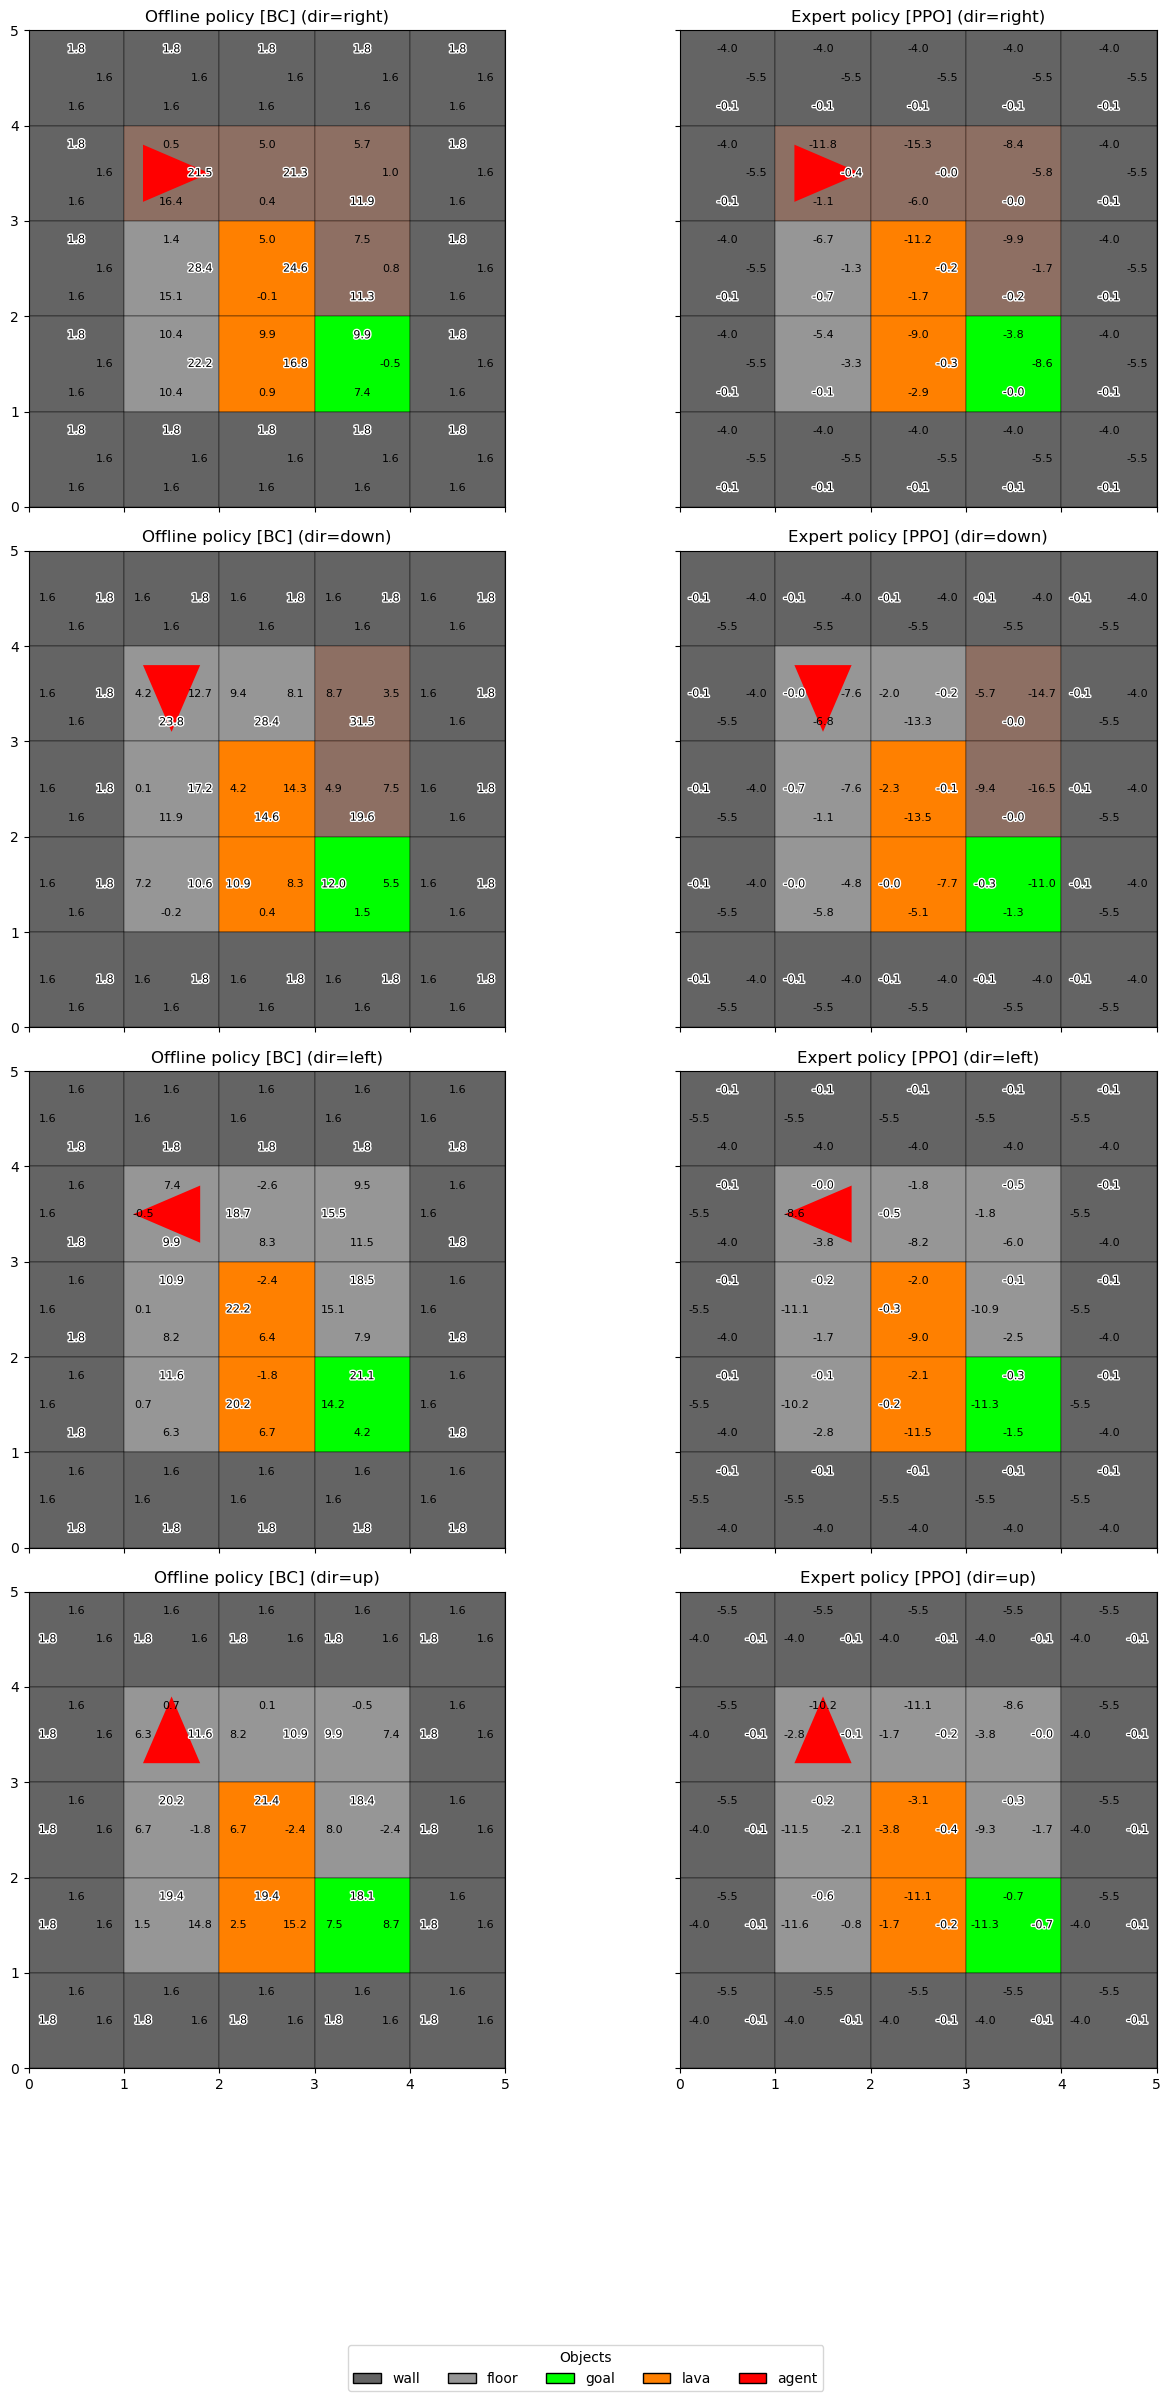

In [43]:
visualize_q_and_expert_visitation("bc")

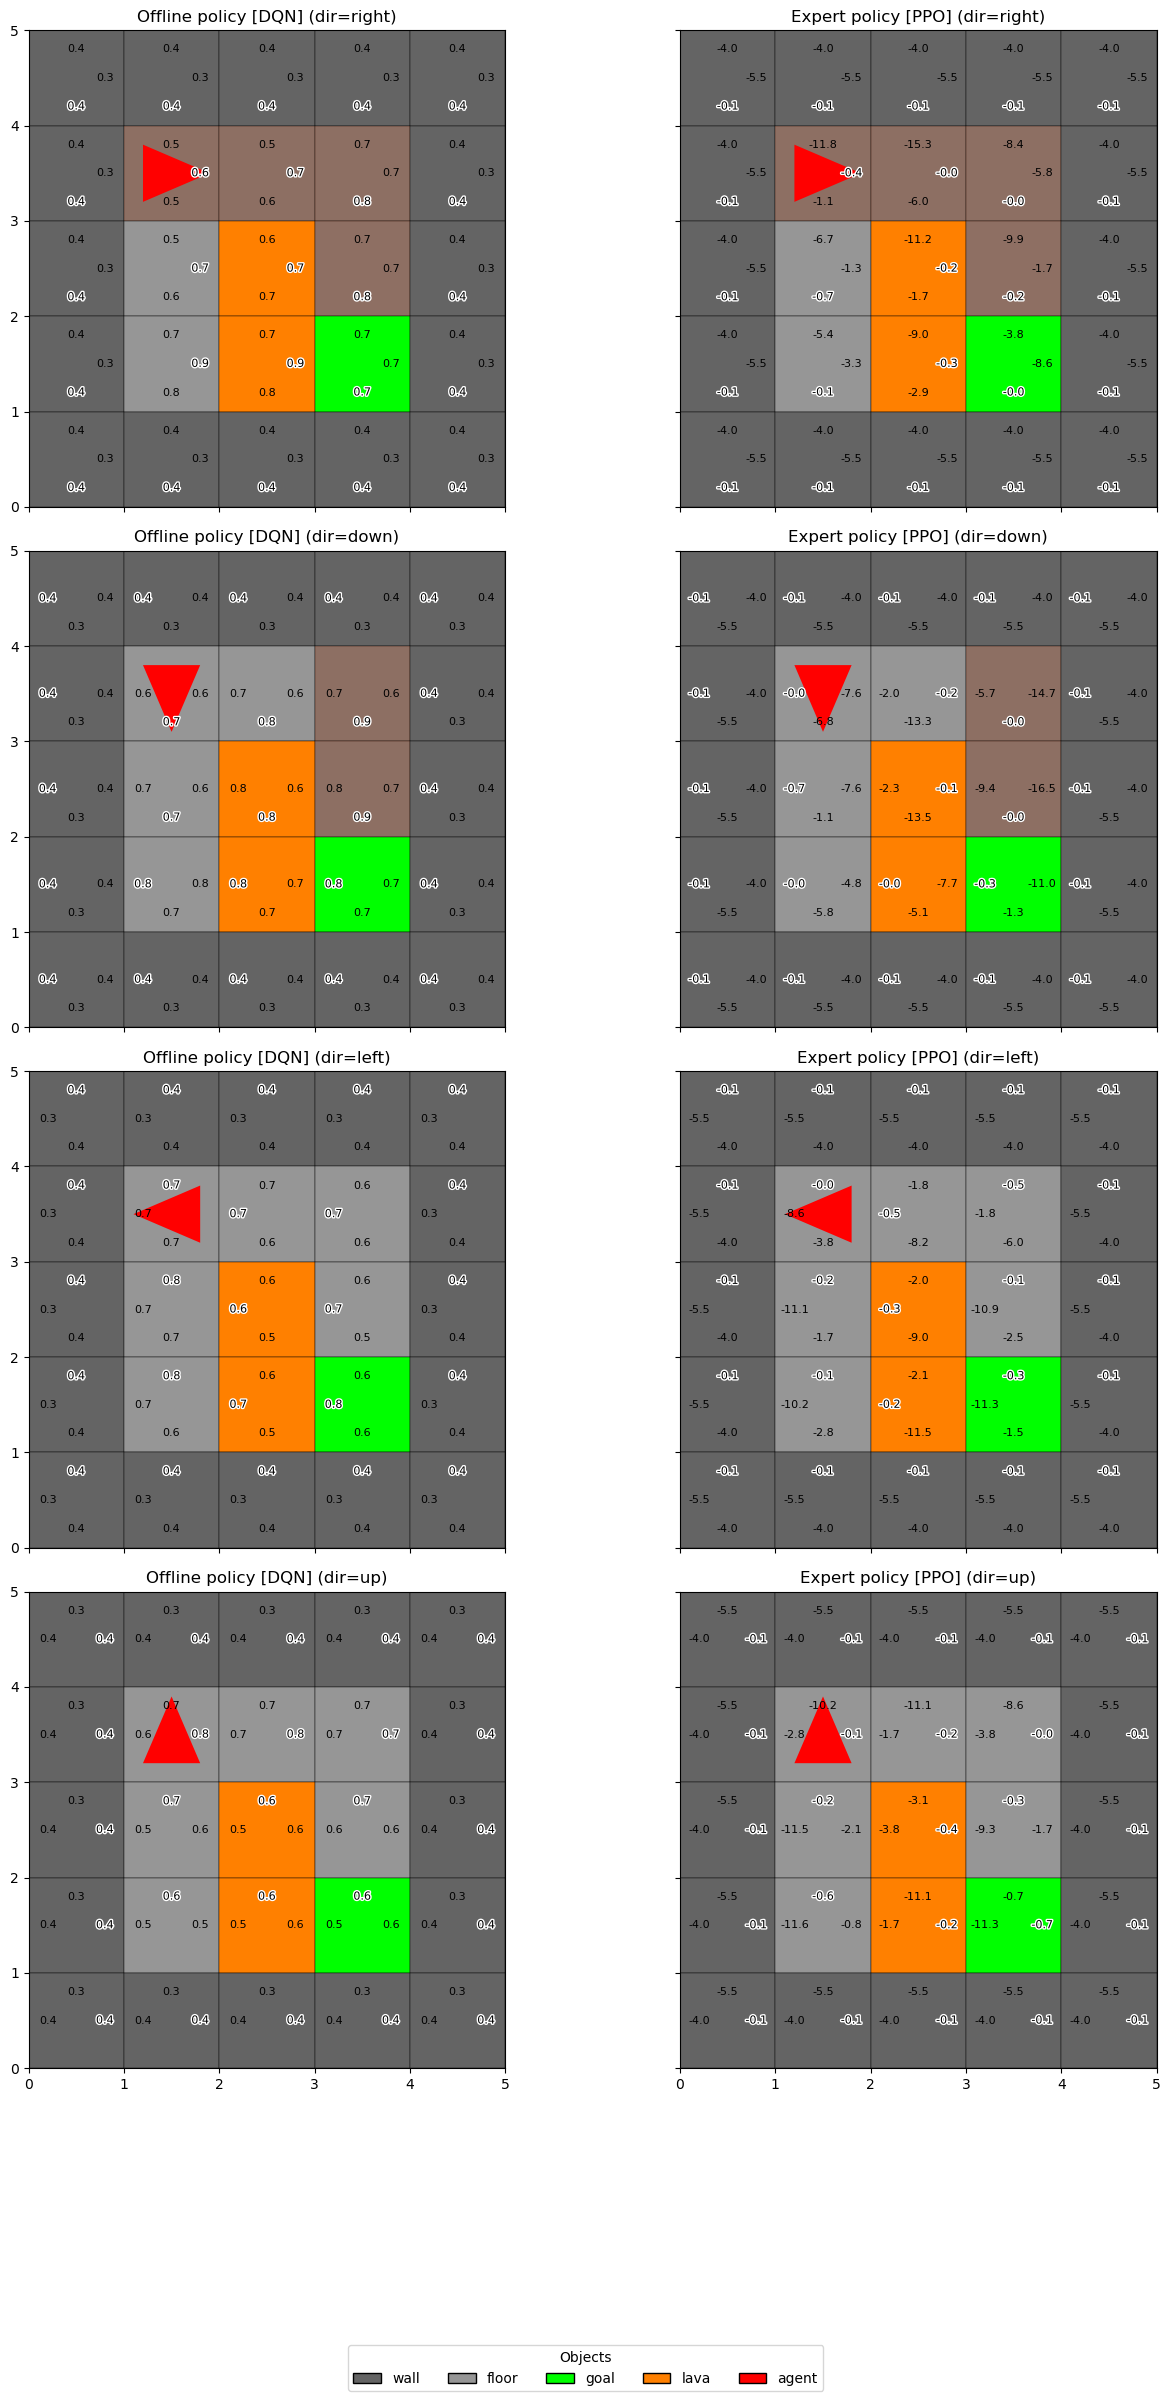

In [44]:
visualize_q_and_expert_visitation("dqn")